In [1]:
# краткая документация по назначению ноутбука
"""
назначение: проверка прироста качества от pattern-признаков elliptic.
основные шаги: загрузка enriched dataset, формирование ablation-наборов,
обучение lightgbm, randomforest, mlp и graphsage, сравнение метрик,
построение feature importance и сохранение результатов.
зависимости и данные: pandas, numpy, sklearn, lightgbm, torch,
elliptic_enriched_features_with_classes.csv, elliptic_txs_edgelist.csv.
ключевые переменные:
- enriched_df: таблица исходных elliptic features вместе с fan, peel и burst признаками.
- feature_groups: словарь групп признаков для ablation-сценариев.
- split_masks: временные маски train, val и test без перемешивания будущего в прошлое.
- results_df: итоговые метрики моделей по каждому набору признаков.
- importance_df: важности признаков lightgbm для интерпретации вклада pattern-групп.
принцип функций:
- prepare_xy получает dataframe и список признаков, возвращает матрицы x/y для модели.
- train-функции получают feature set, обучают модель и возвращают единый набор метрик.
- graphsage использует enriched features как признаки узлов и агрегирует соседей по edge_index.
- ablation сравнивает base, base+fan, base+fan+peel, all patterns и patterns only.
гипотезы:
- прирост f1 после добавления группы признаков показывает ее практическую ценность.
- patterns only служит sanity check и не должен стабильно превосходить полный набор.
- feature importance нужна для проверки, какие pattern-признаки реально используются моделью.
"""

from pathlib import Path
import random
import shutil
import warnings

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    import lightgbm as lgb
except ImportError:
    lgb = None

try:
    import torch
    from torch import nn
except ImportError:
    torch = None
    nn = None

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
DEVICE = torch.device("cuda" if torch and torch.cuda.is_available() else "cpu") if torch else "cpu"
KAGGLE_MODE = Path("/kaggle/working").exists()
BASE_DIR = Path.cwd().resolve()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent
elif (BASE_DIR / "BITOC_WORK").exists():
    BASE_DIR = BASE_DIR / "BITOC_WORK"
KAGGLE_WORKING = Path("/kaggle/working") if KAGGLE_MODE else BASE_DIR
VIS_DIR = (
    KAGGLE_WORKING / "ablation_visualizations"
    if KAGGLE_MODE
    else BASE_DIR / "vizualizations" / "8-elliptic-pattern-features-ablation"
)
VIS_DIR.mkdir(parents=True, exist_ok=True)


def save_plot(fig, filename: str) -> Path:
    """сохраняет matplotlib figure в PNG и показывает её в ноутбуке."""
    output_path = VIS_DIR / filename
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    print(f"saved visualization: {output_path}")
    display(fig)
    plt.close(fig)
    return output_path


np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
if torch:
    torch.manual_seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
print(f"Device: {DEVICE}")
print(f"visualization_dir={VIS_DIR}")

Device: cuda


# Ablation pattern-признаков для классификации Elliptic

Цель ноутбука: проверить, дают ли новые признаки паттернов прирост качества в задаче классификации транзакций `licit / illicit`.

Сравниваются 5 вариантов данных:

1. Только исходные Elliptic features.
2. Исходные features + Fan-in/Fan-out.
3. Исходные features + Fan-in/Fan-out + Peel Chains.
4. Исходные features + Fan-in/Fan-out + Peel Chains + Burst Patterns.
5. Только pattern-признаки как sanity check.

Модели:

- `LightGBM` как сильная табличная модель.
- `RandomForest` как устойчивый классический baseline.
- `MLP` как нейросеть на табличных признаках.
- `GraphSAGE` как графовая нейросеть.

Pattern-признаки можно использовать в GNN: они добавляются в матрицу признаков узлов `X`, после чего GraphSAGE агрегирует уже обогащённые признаки соседей.

In [2]:
# задаем пути к enriched dataset и ребрам графа
PROJECT_ROOT = Path.cwd()
DATA_PATH = "/kaggle/input/datasets/marinade/pattern-data/elliptic_enriched_features_with_classes.csv"
EDGE_CANDIDATES = [
    Path(
        "/kaggle/input/datasets/organizations/ellipticco/"
        "elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv"
    ),
    Path("/kaggle/input/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv"),
    PROJECT_ROOT / "elliptic_bitcoin_dataset" / "elliptic_txs_edgelist.csv",
    PROJECT_ROOT / "BITOC_WORK" / "data" / "elliptic_txs_edgelist.csv",
]
OUTPUT_DIR = KAGGLE_WORKING / "outputs" / "elliptic_pattern_ablation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# вход: список путей-кандидатов; выход: первый существующий путь или none для пропуска graph-блока.
def find_existing_path(candidates):
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


EDGES_PATH = find_existing_path(EDGE_CANDIDATES)

print(f"Data path: {DATA_PATH}")
print(f"Edges path: {EDGES_PATH}")
print(f"Output directory: {OUTPUT_DIR}")

Data path: /kaggle/input/datasets/marinade/pattern-data/elliptic_enriched_features_with_classes.csv
Edges path: /kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv
Output directory: /kaggle/working/BITOC_WORK/outputs/elliptic_pattern_ablation


In [3]:
# загружаем enriched dataset и оставляем только размеченные licit/illicit узлы
# df содержит enriched dataset с base и pattern features; label может быть восстановлен из class.
df = pd.read_csv(DATA_PATH)

if "label" not in df.columns:
    df["label"] = df["class"].astype(str).map({"1": 1, "2": 0})

# labeled_df исключает unknown, потому что ablation оценивает бинарную задачу licit/illicit.
labeled_df = df[df["label"].notna()].copy()
labeled_df["label"] = labeled_df["label"].astype(int)

print(f"Full dataset shape: {df.shape}")
print(f"Labeled dataset shape: {labeled_df.shape}")
print(labeled_df["label"].value_counts().rename({0: "licit", 1: "illicit"}))
print(f"Time steps: {labeled_df['time_step'].min()}..{labeled_df['time_step'].max()}")

Full dataset shape: (203769, 205)
Labeled dataset shape: (46564, 205)
label
licit      42019
illicit     4545
Name: count, dtype: int64
Time steps: 1..49


## Группы признаков и temporal split

Используется честная временная схема:

- `train`: `time_step <= 28`;
- `validation`: `29 <= time_step <= 34`;
- `test`: `time_step >= 35`.

Порог классификации подбирается на validation по максимуму `F1 illicit`, затем применяется к test.

In [4]:
# выделяем исходные и pattern-признаки

def deduplicate_columns(columns):
    # сохраняем порядок и убираем повторяющиеся признаки
    return list(dict.fromkeys(columns))


# base_features повторяет исходное пространство elliptic и служит контрольным baseline.
base_features = [
    col for col in labeled_df.columns
    if col.startswith("feature_") and col.replace("feature_", "").isdigit()
]
base_features = deduplicate_columns(["time_step"] + base_features)

# fan_features проверяет вклад fan-in, fan-out и bipartite hub-признаков.
fan_features = [
    col for col in [
        "in_degree",
        "out_degree",
        "z_in",
        "z_out",
        "is_fanin_hub",
        "is_fanout_hub",
        "is_bipartite_hub",
        "anomalousness_score",
        "hub_type_code",
    ]
    if col in labeled_df.columns
]

# peel_features и burst_features берутся по префиксам, потому что эти группы экспортируются пакетно.
peel_features = [col for col in labeled_df.columns if col.startswith("peel_")]

burst_features = [
    col for col in labeled_df.columns
    if col.startswith("burst_")
    or col in {
        "in_events",
        "out_events",
        "total_events",
        "in_events_z",
        "out_events_z",
        "total_events_z",
        "degree_z",
        "neighbor_degree_sum_z",
        "feature_volume_proxy_z",
        "is_burst_iforest",
    }
]

fan_features = deduplicate_columns(fan_features)
peel_features = deduplicate_columns(peel_features)
burst_features = deduplicate_columns(burst_features)
pattern_features = deduplicate_columns(fan_features + peel_features + burst_features)

# feature_variants задает ablation-лестницу: от base к последовательному добавлению pattern-групп.
feature_variants = {
    "base": base_features,
    "base_fan": deduplicate_columns(base_features + fan_features),
    "base_fan_peel": deduplicate_columns(base_features + fan_features + peel_features),
    "base_fan_peel_burst": deduplicate_columns(
        base_features + fan_features + peel_features + burst_features
    ),
    "patterns_only": pattern_features,
}

for name, cols in feature_variants.items():
    duplicate_count = len(cols) - len(set(cols))
    print(f"{name}: {len(cols)} features, duplicates: {duplicate_count}")

base: 166 features, duplicates: 0
base_fan: 175 features, duplicates: 0
base_fan_peel: 186 features, duplicates: 0
base_fan_peel_burst: 199 features, duplicates: 0
patterns_only: 33 features, duplicates: 0


In [5]:
# формируем временные маски train/val/test
# temporal split не перемешивает время: train обучается на прошлом, test проверяется на будущих шагах.
train_mask = labeled_df["time_step"] <= 28
val_mask = labeled_df["time_step"].between(29, 34)
test_mask = labeled_df["time_step"] >= 35

# y_* хранят бинарные метки в тех же split, что и матрицы признаков.
y_train = labeled_df.loc[train_mask, "label"].to_numpy()
y_val = labeled_df.loc[val_mask, "label"].to_numpy()
y_test = labeled_df.loc[test_mask, "label"].to_numpy()

split_summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "rows": [train_mask.sum(), val_mask.sum(), test_mask.sum()],
    "illicit": [y_train.sum(), y_val.sum(), y_test.sum()],
    "licit": [(y_train == 0).sum(), (y_val == 0).sum(), (y_test == 0).sum()],
})
split_summary

,split,rows,illicit,licit
0,train,25207,2542,22665
1,val,4687,920,3767
2,test,16670,1083,15587


In [6]:
# общие функции подготовки данных и оценки качества

# вход: набор колонок варианта; выход: x_train, x_val и x_test с одинаковым temporal split.
def get_variant_matrices(frame, columns):
    x_train = frame.loc[train_mask, columns].replace([np.inf, -np.inf], np.nan)
    x_val = frame.loc[val_mask, columns].replace([np.inf, -np.inf], np.nan)
    x_test = frame.loc[test_mask, columns].replace([np.inf, -np.inf], np.nan)
    return x_train, x_val, x_test


# вход: val-метки и вероятности; выход: порог, максимизирующий f1 на validation.
def choose_threshold(y_true, y_score):
    thresholds = np.linspace(0.05, 0.95, 181)
    scores = []
    for threshold in thresholds:
        pred = (y_score >= threshold).astype(int)
        scores.append(f1_score(y_true, pred, zero_division=0))
    best_idx = int(np.argmax(scores))
    return float(thresholds[best_idx]), float(scores[best_idx])


def precision_at_k(y_true, y_score, frac=0.01):
    k = max(1, int(len(y_true) * frac))
    order = np.argsort(-y_score)
    return float(y_true[order[:k]].mean())


# вход: test-score и выбранный порог; выход: единая строка метрик для таблицы ablation.
def evaluate_scores(model_name, variant_name, y_true, y_score, threshold):
    pred = (y_score >= threshold).astype(int)
    return {
        "model": model_name,
        "variant": variant_name,
        "threshold": threshold,
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, pred),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
        "precision_at_1pct": precision_at_k(y_true, y_score, frac=0.01),
        "precision_at_5pct": precision_at_k(y_true, y_score, frac=0.05),
    }


# results хранит итоговые метрики, prediction_store сохраняет test-score для последующего анализа.
# val_prediction_store нужен для честного подбора порога и Soft Voting без подглядывания в test.
results = []
prediction_store = {}
val_prediction_store = {}
threshold_store = {}

## Классические модели

Используются две модели:

- `LightGBM`: сильная boosting-модель для табличных данных.
- `RandomForest`: классический ensemble baseline.

Обе модели обучаются на каждом варианте признаков.

In [7]:
# обучаем LightGBM на всех вариантах признаков
lgb_models = {}

if lgb is None:
    print("LightGBM is not installed. Install lightgbm to run this section.")
else:
    for variant_name, columns in feature_variants.items():
        print(f"LightGBM variant: {variant_name}")
        x_train, x_val, x_test = get_variant_matrices(labeled_df, columns)

        # train_data и val_data используют один и тот же список columns, чтобы сравнение вариантов было честным.
        train_data = lgb.Dataset(x_train, label=y_train, feature_name=columns)
        val_data = lgb.Dataset(x_val, label=y_val, reference=train_data, feature_name=columns)

        # pos_weight компенсирует сильный дисбаланс licit/illicit в train-части.
        pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
        params = {
            "objective": "binary",
            "metric": "auc",
            "boosting_type": "gbdt",
            "learning_rate": 0.03,
            "num_leaves": 63,
            "max_depth": -1,
            "feature_fraction": 0.85,
            "bagging_fraction": 0.85,
            "bagging_freq": 1,
            "min_data_in_leaf": 50,
            "scale_pos_weight": pos_weight,
            "seed": RANDOM_STATE,
            "verbose": -1,
        }

        model = lgb.train(
            params,
            train_data,
            valid_sets=[val_data],
            num_boost_round=1500,
            callbacks=[
                lgb.early_stopping(stopping_rounds=100, verbose=False),
                lgb.log_evaluation(period=200),
            ],
        )

        val_score = model.predict(x_val, num_iteration=model.best_iteration)
        threshold, val_f1 = choose_threshold(y_val, val_score)
        test_score = model.predict(x_test, num_iteration=model.best_iteration)

        results.append(evaluate_scores("LightGBM", variant_name, y_test, test_score, threshold))
        prediction_store[("LightGBM", variant_name)] = test_score
        val_prediction_store[("LightGBM", variant_name)] = val_score
        threshold_store[("LightGBM", variant_name)] = threshold
        lgb_models[variant_name] = model

        print(f"Best iteration: {model.best_iteration}")
        print(f"Validation F1: {val_f1:.4f}, threshold: {threshold:.3f}")

LightGBM variant: base
[200]	valid_0's auc: 0.995458
[400]	valid_0's auc: 0.996927
[600]	valid_0's auc: 0.997171
[800]	valid_0's auc: 0.997303
Best iteration: 812
Validation F1: 0.9630, threshold: 0.195
LightGBM variant: base_fan
[200]	valid_0's auc: 0.995644
[400]	valid_0's auc: 0.997164
[600]	valid_0's auc: 0.997378
Best iteration: 695
Validation F1: 0.9619, threshold: 0.175
LightGBM variant: base_fan_peel
[200]	valid_0's auc: 0.995345
[400]	valid_0's auc: 0.996833
[600]	valid_0's auc: 0.997141
Best iteration: 648
Validation F1: 0.9614, threshold: 0.185
LightGBM variant: base_fan_peel_burst
[200]	valid_0's auc: 0.995701
[400]	valid_0's auc: 0.997043
[600]	valid_0's auc: 0.997347
[800]	valid_0's auc: 0.997404
Best iteration: 706
Validation F1: 0.9666, threshold: 0.110
LightGBM variant: patterns_only
Best iteration: 13
Validation F1: 0.7058, threshold: 0.320


In [8]:
# обучаем RandomForest на всех вариантах признаков
rf_models = {}

for variant_name, columns in feature_variants.items():
    print(f"RandomForest variant: {variant_name}")
    x_train, x_val, x_test = get_variant_matrices(labeled_df, columns)

    # pipeline закрывает пропуски медианой и затем обучает balanced random forest.
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("rf", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=3,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ])
    model.fit(x_train, y_train)

    val_score = model.predict_proba(x_val)[:, 1]
    threshold, val_f1 = choose_threshold(y_val, val_score)
    test_score = model.predict_proba(x_test)[:, 1]

    results.append(evaluate_scores("RandomForest", variant_name, y_test, test_score, threshold))
    prediction_store[("RandomForest", variant_name)] = test_score
    val_prediction_store[("RandomForest", variant_name)] = val_score
    threshold_store[("RandomForest", variant_name)] = threshold
    rf_models[variant_name] = model

    print(f"Validation F1: {val_f1:.4f}, threshold: {threshold:.3f}")

RandomForest variant: base
Validation F1: 0.9612, threshold: 0.400
RandomForest variant: base_fan
Validation F1: 0.9619, threshold: 0.395
RandomForest variant: base_fan_peel
Validation F1: 0.9605, threshold: 0.360
RandomForest variant: base_fan_peel_burst
Validation F1: 0.9620, threshold: 0.375
RandomForest variant: patterns_only
Validation F1: 0.6722, threshold: 0.410


## Нейронные модели

Используются две модели:

- `MLP`: нейросеть на табличных признаках.
- `GraphSAGE`: графовая нейросеть, где новые pattern-признаки добавляются в `X` как обычные признаки узлов.

GraphSAGE реализован на чистом PyTorch через sparse adjacency aggregation, поэтому `torch_geometric` не требуется. Секция будет пропущена только если не установлен `torch` или не найден файл ребер.

In [9]:
# вспомогательные функции для MLP
if torch:
    from torch.utils.data import DataLoader, TensorDataset

    # TabularMLP служит нейросетевым baseline для сравнения с деревьями на тех же feature variants.
    class TabularMLP(nn.Module):
        def __init__(self, input_dim):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(input_dim, 512),
                nn.BatchNorm1d(512),
                nn.SiLU(),
                nn.Dropout(0.30),
                nn.Linear(512, 256),
                nn.BatchNorm1d(256),
                nn.SiLU(),
                nn.Dropout(0.25),
                nn.Linear(256, 128),
                nn.BatchNorm1d(128),
                nn.SiLU(),
                nn.Dropout(0.15),
                nn.Linear(128, 1),
            )

        def forward(self, x):
            return self.net(x).squeeze(-1)


# вход: имя варианта и признаки; выход: обученная mlp и test-score для общей таблицы.
def train_mlp_variant(variant_name, columns, epochs=120, batch_size=1024):
    x_train, x_val, x_test = get_variant_matrices(labeled_df, columns)

    # imputer и scaler обучаются только на train, затем применяются к val и test.
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    x_train_np = scaler.fit_transform(imputer.fit_transform(x_train)).astype(np.float32)
    x_val_np = scaler.transform(imputer.transform(x_val)).astype(np.float32)
    x_test_np = scaler.transform(imputer.transform(x_test)).astype(np.float32)

    train_dataset = TensorDataset(
        torch.tensor(x_train_np, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32),
    )
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    model = TabularMLP(input_dim=x_train_np.shape[1]).to(DEVICE)
    pos_weight = torch.tensor([(y_train == 0).sum() / max((y_train == 1).sum(), 1)], device=DEVICE)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.0008, weight_decay=3e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=4,
    )

    # best_* хранит состояние с лучшим val f1, patience останавливает обучение без улучшения.
    best_state = None
    best_val_f1 = -1
    best_threshold = 0.5
    patience = 8
    patience_left = patience

    for epoch in range(epochs):
        model.train()
        losses = []
        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(DEVICE)
            batch_y = batch_y.to(DEVICE)
            optimizer.zero_grad()
            logits = model(batch_x)
            loss = loss_fn(logits, batch_y)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_logits = model(torch.tensor(x_val_np, dtype=torch.float32, device=DEVICE))
            val_score = torch.sigmoid(val_logits).cpu().numpy()
        threshold, val_f1 = choose_threshold(y_val, val_score)
        scheduler.step(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_threshold = threshold
            best_state = {key: value.cpu().clone() for key, value in model.state_dict().items()}
            patience_left = patience
        else:
            patience_left -= 1

        if epoch in {0, 9, 24, 49}:
            print(f"MLP {variant_name} epoch {epoch + 1}: loss {np.mean(losses):.6f}, val_f1 {val_f1:.4f}")
        if patience_left == 0:
            break

    model.load_state_dict(best_state)
    model.to(DEVICE)
    model.eval()
    with torch.no_grad():
        val_logits = model(torch.tensor(x_val_np, dtype=torch.float32, device=DEVICE))
        val_score = torch.sigmoid(val_logits).cpu().numpy()
        test_logits = model(torch.tensor(x_test_np, dtype=torch.float32, device=DEVICE))
        test_score = torch.sigmoid(test_logits).cpu().numpy()

    return model, best_threshold, best_val_f1, val_score, test_score

In [10]:
# обучаем MLP на всех вариантах признаков
mlp_models = {}

if torch is None:
    print("Torch is not installed. MLP section skipped.")
else:
    for variant_name, columns in feature_variants.items():
        print(f"MLP variant: {variant_name}")
        model, threshold, val_f1, val_score, test_score = train_mlp_variant(variant_name, columns)
        results.append(evaluate_scores("MLP", variant_name, y_test, test_score, threshold))
        prediction_store[("MLP", variant_name)] = test_score
        val_prediction_store[("MLP", variant_name)] = val_score
        threshold_store[("MLP", variant_name)] = threshold
        mlp_models[variant_name] = model
        print(f"Best validation F1: {val_f1:.4f}, threshold: {threshold:.3f}")

MLP variant: base
MLP base epoch 1: loss 0.587525, val_f1 0.7070
MLP base epoch 10: loss 0.155404, val_f1 0.8554
MLP base epoch 25: loss 0.097322, val_f1 0.8677
Best validation F1: 0.8745, threshold: 0.695
MLP variant: base_fan
MLP base_fan epoch 1: loss 0.582368, val_f1 0.6918
MLP base_fan epoch 10: loss 0.161252, val_f1 0.8544
MLP base_fan epoch 25: loss 0.099370, val_f1 0.8743
Best validation F1: 0.8884, threshold: 0.800
MLP variant: base_fan_peel
MLP base_fan_peel epoch 1: loss 0.612368, val_f1 0.7058
MLP base_fan_peel epoch 10: loss 0.167637, val_f1 0.8532
MLP base_fan_peel epoch 25: loss 0.087667, val_f1 0.8768
Best validation F1: 0.8797, threshold: 0.930
MLP variant: base_fan_peel_burst
MLP base_fan_peel_burst epoch 1: loss 0.632048, val_f1 0.6775
MLP base_fan_peel_burst epoch 10: loss 0.163949, val_f1 0.8648
Best validation F1: 0.8824, threshold: 0.860
MLP variant: patterns_only
MLP patterns_only epoch 1: loss 0.852939, val_f1 0.4760
MLP patterns_only epoch 10: loss 0.628307, v

In [11]:
# готовим sparse adjacency для GraphSAGE без torch_geometric

# вход: dataframe узлов и edgelist; выход: row-normalized sparse adjacency для mean aggregation.
def build_graphsage_adjacency(frame, edges_path):
    if torch is None or edges_path is None or not edges_path.exists():
        return None

    edges = pd.read_csv(edges_path)
    # tx_to_idx переводит реальные txId в позиции строк df, которые используются в sparse adjacency.
    tx_to_idx = {tx_id: idx for idx, tx_id in enumerate(frame["txId"])}
    src = edges["txId1"].map(tx_to_idx)
    dst = edges["txId2"].map(tx_to_idx)
    valid = src.notna() & dst.notna()

    src = src[valid].astype(int).to_numpy()
    dst = dst[valid].astype(int).to_numpy()

    # делаем граф неориентированным: соседская агрегация идет в обе стороны
    row = np.concatenate([dst, src])
    col = np.concatenate([src, dst])
    n_nodes = len(frame)

    degree = np.bincount(row, minlength=n_nodes).astype(np.float32)
    degree[degree == 0] = 1.0
    values = 1.0 / degree[row]

    indices = torch.tensor(np.vstack([row, col]), dtype=torch.long)
    values = torch.tensor(values, dtype=torch.float32)
    adjacency = torch.sparse_coo_tensor(
        indices,
        values,
        size=(n_nodes, n_nodes),
    ).coalesce()
    return adjacency


sage_adj = build_graphsage_adjacency(df, EDGES_PATH)
if sage_adj is not None:
    print(f"GraphSAGE adjacency shape: {tuple(sage_adj.shape)}")
    print(f"GraphSAGE adjacency nnz: {sage_adj._nnz()}")
else:
    print("GraphSAGE adjacency is not available")

GraphSAGE adjacency shape: (203769, 203769)
GraphSAGE adjacency nnz: 468710


In [12]:
# вспомогательные функции для GraphSAGE на чистом PyTorch
if torch:
    # MeanSAGELayer объединяет собственные признаки узла и средние признаки соседей.
    class MeanSAGELayer(nn.Module):
        def __init__(self, input_dim, output_dim):
            super().__init__()
            self.self_linear = nn.Linear(input_dim, output_dim)
            self.neighbor_linear = nn.Linear(input_dim, output_dim)

        def forward(self, x, adjacency):
            # adjacency уже нормирована по строкам и дает среднее по соседям
            neighbor_mean = torch.sparse.mm(adjacency, x)
            return self.self_linear(x) + self.neighbor_linear(neighbor_mean)


    # GraphSAGEClassifier проверяет, усиливают ли pattern-признаки графовую модель на тех же split.
    class GraphSAGEClassifier(nn.Module):
        def __init__(self, input_dim, hidden_dim=256):
            super().__init__()
            self.input_norm = nn.LayerNorm(input_dim)
            self.conv1 = MeanSAGELayer(input_dim, hidden_dim)
            self.norm1 = nn.LayerNorm(hidden_dim)
            self.conv2 = MeanSAGELayer(hidden_dim, hidden_dim)
            self.norm2 = nn.LayerNorm(hidden_dim)
            self.head = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.SiLU(),
                nn.Dropout(0.20),
                nn.Linear(hidden_dim // 2, 1),
            )
            self.dropout = nn.Dropout(0.20)

        def encode(self, x, adjacency):
            x = self.input_norm(x)
            h1 = self.norm1(self.conv1(x, adjacency)).relu()
            h1 = self.dropout(h1)
            h2 = self.norm2(self.conv2(h1, adjacency)).relu()
            return self.dropout(h2)

        def forward(self, x, adjacency):
            return self.head(self.encode(x, adjacency)).squeeze(-1)


# вход: вариант признаков; выход: обученный graphsage и score на test-узлах.
def train_graphsage_variant(variant_name, columns, epochs=180):
    x_all = df[columns].replace([np.inf, -np.inf], np.nan)
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    x_all_np = scaler.fit_transform(imputer.fit_transform(x_all)).astype(np.float32)

    label_series = df["label"].copy()
    if label_series.isna().any():
        label_series = label_series.fillna(-1)
    y_all = label_series.astype(int).to_numpy()

    # индексы split считаются по full df, чтобы они совпадали с adjacency и всеми узлами графа.
    train_idx = df.index[df["label"].notna() & (df["time_step"] <= 28)].to_numpy()
    val_idx = df.index[df["label"].notna() & df["time_step"].between(29, 34)].to_numpy()
    test_idx = df.index[df["label"].notna() & (df["time_step"] >= 35)].to_numpy()

    x = torch.tensor(x_all_np, dtype=torch.float32, device=DEVICE)
    y = torch.tensor(y_all, dtype=torch.float32, device=DEVICE)
    train_idx_t = torch.tensor(train_idx, dtype=torch.long, device=DEVICE)
    val_idx_t = torch.tensor(val_idx, dtype=torch.long, device=DEVICE)
    test_idx_t = torch.tensor(test_idx, dtype=torch.long, device=DEVICE)
    adjacency = sage_adj.to(DEVICE)

    model = GraphSAGEClassifier(input_dim=x.shape[1]).to(DEVICE)
    pos_weight = torch.tensor([(y_train == 0).sum() / max((y_train == 1).sum(), 1)], device=DEVICE)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.002, weight_decay=3e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=6,
    )

    best_state = None
    best_val_f1 = -1
    best_threshold = 0.5
    patience = 15
    patience_left = patience

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(x, adjacency)
        loss = loss_fn(logits[train_idx_t], y[train_idx_t])
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits = model(x, adjacency)
            val_score = torch.sigmoid(logits[val_idx_t]).cpu().numpy()
        threshold, val_f1 = choose_threshold(y_val, val_score)
        scheduler.step(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_threshold = threshold
            best_state = {key: value.cpu().clone() for key, value in model.state_dict().items()}
            patience_left = patience
        else:
            patience_left -= 1

        if epoch in {0, 24, 49, 99}:
            print(f"GraphSAGE {variant_name} epoch {epoch + 1}: loss {loss.item():.6f}, val_f1 {val_f1:.4f}")
        if patience_left == 0:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.to(DEVICE)
    model.eval()
    with torch.no_grad():
        logits = model(x, adjacency)
        val_score = torch.sigmoid(logits[val_idx_t]).cpu().numpy()
        test_score = torch.sigmoid(logits[test_idx_t]).cpu().numpy()

    return model, best_threshold, best_val_f1, val_score, test_score

In [13]:
# обучаем GraphSAGE на всех вариантах признаков
graphsage_models = {}

if torch is None or sage_adj is None:
    print("GraphSAGE section skipped. Need torch and edgelist file.")
else:
    for variant_name, columns in feature_variants.items():
        print(f"GraphSAGE variant: {variant_name}")
        model, threshold, val_f1, val_score, test_score = train_graphsage_variant(variant_name, columns)
        results.append(evaluate_scores("GraphSAGE", variant_name, y_test, test_score, threshold))
        prediction_store[("GraphSAGE", variant_name)] = test_score
        val_prediction_store[("GraphSAGE", variant_name)] = val_score
        threshold_store[("GraphSAGE", variant_name)] = threshold
        graphsage_models[variant_name] = model
        print(f"Best validation F1: {val_f1:.4f}, threshold: {threshold:.3f}")

GraphSAGE variant: base
GraphSAGE base epoch 1: loss 1.217961, val_f1 0.4808
GraphSAGE base epoch 25: loss 0.283246, val_f1 0.7559
GraphSAGE base epoch 50: loss 0.138604, val_f1 0.8770
GraphSAGE base epoch 100: loss 0.045088, val_f1 0.8956
Best validation F1: 0.8995, threshold: 0.885
GraphSAGE variant: base_fan
GraphSAGE base_fan epoch 1: loss 1.498119, val_f1 0.4372
GraphSAGE base_fan epoch 25: loss 0.301189, val_f1 0.7679
GraphSAGE base_fan epoch 50: loss 0.155884, val_f1 0.8707
Best validation F1: 0.8856, threshold: 0.925
GraphSAGE variant: base_fan_peel
GraphSAGE base_fan_peel epoch 1: loss 1.279470, val_f1 0.4573
GraphSAGE base_fan_peel epoch 25: loss 0.280704, val_f1 0.7261
GraphSAGE base_fan_peel epoch 50: loss 0.137784, val_f1 0.8638
GraphSAGE base_fan_peel epoch 100: loss 0.041950, val_f1 0.8826
Best validation F1: 0.8836, threshold: 0.925
GraphSAGE variant: base_fan_peel_burst
GraphSAGE base_fan_peel_burst epoch 1: loss 1.263927, val_f1 0.4930
GraphSAGE base_fan_peel_burst ep

## Усиленные графовые модели и Soft Voting

Добавлены три модели для расширенного сравнения:

- `SAGE-DGI-MLP`: GraphSAGE encoder с DGI-регуляризацией и MLP-head;
- `SAGE-WaveGate`: multi-hop GraphSAGE с обучаемым gate между self/1-hop/2-hop представлениями;
- `Soft Voting`: validation-weighted усреднение вероятностей доступных сильных моделей.

Все пороги подбираются только на validation, test используется только для финальной оценки.

In [ ]:
# расширенные GNN-модели и Soft Voting

ADVANCED_SAGE_EPOCHS = 160
DGI_WEIGHT = 0.03

if torch:
    class SAGEDGIMLPClassifier(nn.Module):
        def __init__(self, input_dim, hidden_dim=192):
            super().__init__()
            self.input_norm = nn.LayerNorm(input_dim)
            self.conv1 = MeanSAGELayer(input_dim, hidden_dim)
            self.norm1 = nn.LayerNorm(hidden_dim)
            self.conv2 = MeanSAGELayer(hidden_dim, hidden_dim)
            self.norm2 = nn.LayerNorm(hidden_dim)
            self.dropout = nn.Dropout(0.20)
            self.head = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.SiLU(),
                nn.Dropout(0.20),
                nn.Linear(hidden_dim, 1),
            )

        def encode(self, x, adjacency):
            x = self.input_norm(x)
            h = self.norm1(self.conv1(x, adjacency)).relu()
            h = self.dropout(h)
            h = self.norm2(self.conv2(h, adjacency)).relu()
            return self.dropout(h)

        def forward(self, x, adjacency):
            return self.head(self.encode(x, adjacency)).squeeze(-1)


    class SAGEWaveGateClassifier(nn.Module):
        def __init__(self, input_dim, hidden_dim=192):
            super().__init__()
            self.input_norm = nn.LayerNorm(input_dim)
            self.self_proj = nn.Linear(input_dim, hidden_dim)
            self.conv1 = MeanSAGELayer(input_dim, hidden_dim)
            self.conv2 = MeanSAGELayer(hidden_dim, hidden_dim)
            self.gate = nn.Sequential(
                nn.Linear(hidden_dim * 3, hidden_dim),
                nn.SiLU(),
                nn.Linear(hidden_dim, 3),
                nn.Softmax(dim=1),
            )
            self.norm = nn.LayerNorm(hidden_dim)
            self.dropout = nn.Dropout(0.20)
            self.head = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.SiLU(),
                nn.Dropout(0.20),
                nn.Linear(hidden_dim // 2, 1),
            )

        def encode(self, x, adjacency):
            x = self.input_norm(x)
            h0 = self.self_proj(x).relu()
            h1 = self.conv1(x, adjacency).relu()
            h2 = self.conv2(h1, adjacency).relu()
            gates = self.gate(torch.cat([h0, h1, h2], dim=1))
            h = gates[:, 0:1] * h0 + gates[:, 1:2] * h1 + gates[:, 2:3] * h2
            return self.dropout(self.norm(h))

        def forward(self, x, adjacency):
            return self.head(self.encode(x, adjacency)).squeeze(-1)


def _prepare_graph_tensors(columns):
    x_all = df[columns].replace([np.inf, -np.inf], np.nan)
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    x_all_np = scaler.fit_transform(imputer.fit_transform(x_all)).astype(np.float32)

    label_series = df["label"].copy()
    if label_series.isna().any():
        label_series = label_series.fillna(-1)
    y_all = label_series.astype(int).to_numpy()

    train_idx = df.index[df["label"].notna() & (df["time_step"] <= 28)].to_numpy()
    val_idx = df.index[df["label"].notna() & df["time_step"].between(29, 34)].to_numpy()
    test_idx = df.index[df["label"].notna() & (df["time_step"] >= 35)].to_numpy()

    x = torch.tensor(x_all_np, dtype=torch.float32, device=DEVICE)
    y = torch.tensor(y_all, dtype=torch.float32, device=DEVICE)
    train_idx_t = torch.tensor(train_idx, dtype=torch.long, device=DEVICE)
    val_idx_t = torch.tensor(val_idx, dtype=torch.long, device=DEVICE)
    test_idx_t = torch.tensor(test_idx, dtype=torch.long, device=DEVICE)
    return x, y, train_idx_t, val_idx_t, test_idx_t


def _dgi_regularization(model, x, adjacency, train_idx_t):
    h_pos = model.encode(x, adjacency)
    perm = torch.randperm(x.shape[0], device=DEVICE)
    h_neg = model.encode(x[perm], adjacency)
    summary = torch.sigmoid(h_pos[train_idx_t].mean(dim=0))
    pos_logits = (h_pos[train_idx_t] * summary).sum(dim=1)
    neg_logits = (h_neg[train_idx_t] * summary).sum(dim=1)
    labels = torch.cat([torch.ones_like(pos_logits), torch.zeros_like(neg_logits)])
    logits = torch.cat([pos_logits, neg_logits])
    return nn.BCEWithLogitsLoss()(logits, labels)


def train_advanced_sage_variant(model_name, model_class, variant_name, columns, epochs=ADVANCED_SAGE_EPOCHS, dgi_weight=0.0):
    x, y, train_idx_t, val_idx_t, test_idx_t = _prepare_graph_tensors(columns)
    adjacency = sage_adj.to(DEVICE)
    model = model_class(input_dim=x.shape[1]).to(DEVICE)
    pos_weight = torch.tensor([(y_train == 0).sum() / max((y_train == 1).sum(), 1)], device=DEVICE)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.0015, weight_decay=4e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=6)

    best_state = None
    best_val_f1 = -1
    best_threshold = 0.5
    patience_left = 18

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(x, adjacency)
        loss = loss_fn(logits[train_idx_t], y[train_idx_t])
        if dgi_weight > 0:
            loss = loss + dgi_weight * _dgi_regularization(model, x, adjacency, train_idx_t)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=3.0)
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(x, adjacency)
            val_score = torch.sigmoid(val_logits[val_idx_t]).cpu().numpy()
        threshold, val_f1 = choose_threshold(y_val, val_score)
        scheduler.step(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_threshold = threshold
            best_state = {key: value.cpu().clone() for key, value in model.state_dict().items()}
            patience_left = 18
        else:
            patience_left -= 1

        if epoch in {0, 24, 49, 99, 149}:
            print(f"{model_name} {variant_name} epoch {epoch + 1}: loss {loss.item():.6f}, val_f1 {val_f1:.4f}")
        if patience_left == 0:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.to(DEVICE)
    model.eval()
    with torch.no_grad():
        logits = model(x, adjacency)
        val_score = torch.sigmoid(logits[val_idx_t]).cpu().numpy()
        test_score = torch.sigmoid(logits[test_idx_t]).cpu().numpy()
    return model, best_threshold, best_val_f1, val_score, test_score


advanced_graph_models = {}
if torch is None or sage_adj is None:
    print("Advanced graph models skipped. Need torch and GraphSAGE adjacency.")
else:
    advanced_specs = [
        ("SAGE-DGI-MLP", SAGEDGIMLPClassifier, DGI_WEIGHT),
        ("SAGE-WaveGate", SAGEWaveGateClassifier, 0.0),
    ]
    for model_name, model_class, dgi_weight in advanced_specs:
        for variant_name, columns in feature_variants.items():
            print(f"{model_name} variant: {variant_name}")
            model, threshold, val_f1, val_score, test_score = train_advanced_sage_variant(
                model_name,
                model_class,
                variant_name,
                columns,
                dgi_weight=dgi_weight,
            )
            results.append(evaluate_scores(model_name, variant_name, y_test, test_score, threshold))
            prediction_store[(model_name, variant_name)] = test_score
            val_prediction_store[(model_name, variant_name)] = val_score
            threshold_store[(model_name, variant_name)] = threshold
            advanced_graph_models[(model_name, variant_name)] = model
            print(f"Best validation F1: {val_f1:.4f}, threshold: {threshold:.3f}")


SOFT_VOTING_CANDIDATES = [
    "LightGBM",
    "RandomForest",
    "MLP",
    "GraphSAGE",
    "SAGE-DGI-MLP",
    "SAGE-WaveGate",
]

for variant_name in feature_variants:
    available = [
        model_name
        for model_name in SOFT_VOTING_CANDIDATES
        if (model_name, variant_name) in prediction_store and (model_name, variant_name) in val_prediction_store
    ]
    if len(available) < 2:
        continue

    val_scores = []
    test_scores = []
    weights = []
    for model_name in available:
        val_score = val_prediction_store[(model_name, variant_name)]
        _, val_f1 = choose_threshold(y_val, val_score)
        weights.append(max(val_f1, 1e-3))
        val_scores.append(val_score)
        test_scores.append(prediction_store[(model_name, variant_name)])

    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()
    val_vote = np.average(np.vstack(val_scores), axis=0, weights=weights)
    test_vote = np.average(np.vstack(test_scores), axis=0, weights=weights)
    threshold, val_f1 = choose_threshold(y_val, val_vote)

    results.append(evaluate_scores("Soft Voting", variant_name, y_test, test_vote, threshold))
    prediction_store[("Soft Voting", variant_name)] = test_vote
    val_prediction_store[("Soft Voting", variant_name)] = val_vote
    threshold_store[("Soft Voting", variant_name)] = threshold
    print(
        f"Soft Voting {variant_name}: models={available}, "
        f"val_f1={val_f1:.4f}, threshold={threshold:.3f}"
    )

## Сравнение результатов и feature importance

В этом разделе строятся:

- итоговая таблица метрик;
- график `F1` по моделям и вариантам данных;
- прирост относительно базового набора признаков;
- важность признаков LightGBM для варианта `base_fan_peel_burst`.

In [14]:
# собираем итоговую таблицу метрик
# results_df объединяет все модели и варианты признаков в одну таблицу для дальнейших графиков.
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["model", "variant"]).reset_index(drop=True)
results_df

,model,variant,threshold,precision,recall,f1,mcc,roc_auc,pr_auc,precision_at_1pct,precision_at_5pct
0,GraphSAGE,base,0.885,0.436211,0.625115,0.513852,0.482613,0.868132,0.506411,0.783133,0.591837
1,GraphSAGE,base_fan,0.925,0.396407,0.611265,0.480930,0.448702,0.877734,0.454792,0.704819,0.541417
2,GraphSAGE,base_fan_peel,0.925,0.378437,0.648199,0.477876,0.450046,0.875088,0.451196,0.614458,0.597839
3,GraphSAGE,base_fan_peel_burst,0.895,0.372294,0.635272,0.469464,0.440290,0.870347,0.383746,0.578313,0.468187
4,GraphSAGE,patterns_only,0.545,0.224351,0.638042,0.331972,0.307857,0.812755,0.469160,0.903614,0.575030
5,LightGBM,base,0.195,0.873034,0.717452,0.787633,0.778626,0.928137,0.787730,1.000000,0.918367
6,LightGBM,base_fan,0.175,0.881490,0.721145,0.793296,0.784904,0.928304,0.788820,0.993976,0.923169
7,LightGBM,base_fan_peel,0.185,0.873884,0.722992,0.791309,0.782217,0.931993,0.788841,0.993976,0.920768
8,LightGBM,base_fan_peel_burst,0.110,0.833333,0.724838,0.775309,0.762952,0.931670,0.792064,1.000000,0.919568
9,LightGBM,patterns_only,0.320,0.606710,0.601108,0.603896,0.576518,0.852667,0.584378,0.813253,0.735894


## Визуализации полного сравнения моделей

Этот блок сохраняет дополнительные графики в стиле `1_kaggle_elliptic-data-set-node-classification.ipynb`:

- `all_models_comparison_v2.png`;
- `radar_top5_v2.png`;
- `pr_curves_improved.png`;
- `roc_curves_improved.png`.

Графики строятся по лучшему варианту признаков для каждой модели и используют `prediction_store`, который содержит test-score.

In [ ]:
# дополнительные визуализации в стиле полного сравнения моделей
if not results_df.empty:
    best_model_rows = (
        results_df.sort_values(["model", "f1", "roc_auc"], ascending=[True, False, False])
        .groupby("model", as_index=False)
        .head(1)
        .copy()
        .sort_values("f1", ascending=False)
        .reset_index(drop=True)
    )
    best_model_rows["model_name"] = best_model_rows["model"] + " (" + best_model_rows["variant"] + ")"
    best_model_rows["f1_illicit"] = best_model_rows["f1"]
    best_model_rows["precision_illicit"] = best_model_rows["precision"]
    best_model_rows["recall_illicit"] = best_model_rows["recall"]
    best_model_rows["average_precision"] = best_model_rows["pr_auc"]
    balanced_accuracy_values = []
    for row in best_model_rows.itertuples(index=False):
        key = (row.model, row.variant)
        if key in prediction_store:
            balanced_accuracy_values.append(
                balanced_accuracy_score(
                    y_test,
                    (prediction_store[key] >= row.threshold).astype(int),
                )
            )
        else:
            balanced_accuracy_values.append(np.nan)
    best_model_rows["balanced_accuracy"] = balanced_accuracy_values

    best_model_rows.to_csv(OUTPUT_DIR / "best_model_rows.csv", index=False)

    palette_all = sns.color_palette("tab20", n_colors=len(best_model_rows))
    fig, axes = plt.subplots(1, 2, figsize=(20, max(6, len(best_model_rows) * 0.45 + 1)))

    for ax, (col, label) in zip(axes, [("f1_illicit", "F1 illicit"), ("roc_auc", "ROC-AUC")]):
        bars = ax.barh(
            best_model_rows["model_name"],
            best_model_rows[col].fillna(0),
            color=palette_all,
            edgecolor="white",
            height=0.7,
        )
        for bar, value in zip(bars, best_model_rows[col].fillna(0)):
            ax.text(
                bar.get_width() + 0.005,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.3f}",
                va="center",
                fontsize=8,
            )
        ax.set_title(label)
        ax.set_xlim(0, 1.05)
        ax.invert_yaxis()

    fig.suptitle("Полное сравнение моделей ablation (v2)", fontsize=13, y=1.02)
    fig.tight_layout()
    fig.subplots_adjust(wspace=0.4)
    save_plot(fig, "all_models_comparison_v2.png")

    top5 = best_model_rows.head(5).copy()
    radar_metrics = [
        "f1_illicit",
        "precision_illicit",
        "recall_illicit",
        "balanced_accuracy",
        "roc_auc",
        "average_precision",
    ]
    labels_r = ["F1", "Prec", "Recall", "BalAcc", "ROC-AUC", "AvgP"]
    angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
    angles += angles[:1]
    palette_radar = sns.color_palette("tab10", n_colors=len(top5))

    fig_r, ax_r = plt.subplots(figsize=(7, 7), subplot_kw={"polar": True})
    for idx, (_, row) in enumerate(top5.iterrows()):
        values = [float(row.get(metric, 0) or 0) for metric in radar_metrics]
        values += values[:1]
        ax_r.plot(angles, values, "-o", linewidth=2, color=palette_radar[idx], label=row["model_name"])
        ax_r.fill(angles, values, alpha=0.10, color=palette_radar[idx])

    ax_r.set_xticks(angles[:-1])
    ax_r.set_xticklabels(labels_r, fontsize=10)
    ax_r.set_ylim(0, 1)
    ax_r.set_title("Radar: топ-5 моделей ablation (v2)", pad=18)
    ax_r.legend(loc="lower right", bbox_to_anchor=(1.35, -0.15), fontsize=8)
    fig_r.tight_layout()
    save_plot(fig_r, "radar_top5_v2.png")

    curve_rows = best_model_rows.head(8).copy()

    fig_pr, ax_pr = plt.subplots(figsize=(10, 7))
    for idx, row in enumerate(curve_rows.itertuples(index=False)):
        key = (row.model, row.variant)
        if key not in prediction_store:
            continue
        scores = prediction_store[key]
        precision_curve, recall_curve, _ = precision_recall_curve(y_test, scores)
        avg_precision = average_precision_score(y_test, scores)
        ax_pr.plot(
            recall_curve,
            precision_curve,
            lw=2,
            label=f"{row.model_name} (AP={avg_precision:.3f})",
        )
    baseline_ap = y_test.mean()
    ax_pr.axhline(baseline_ap, color="gray", linestyle="--", label=f"baseline (AP={baseline_ap:.3f})")
    ax_pr.set_xlabel("Recall illicit", fontsize=13)
    ax_pr.set_ylabel("Precision illicit", fontsize=13)
    ax_pr.set_title("Precision-Recall curves: ablation best models", fontsize=14)
    ax_pr.legend(fontsize=9)
    ax_pr.grid(True, alpha=0.3)
    fig_pr.tight_layout()
    save_plot(fig_pr, "pr_curves_improved.png")

    fig_roc, ax_roc = plt.subplots(figsize=(10, 7))
    for idx, row in enumerate(curve_rows.itertuples(index=False)):
        key = (row.model, row.variant)
        if key not in prediction_store:
            continue
        scores = prediction_store[key]
        fpr, tpr, _ = roc_curve(y_test, scores)
        auc_value = roc_auc_score(y_test, scores)
        ax_roc.plot(fpr, tpr, lw=2, label=f"{row.model_name} (AUC={auc_value:.3f})")
    ax_roc.plot([0, 1], [0, 1], color="gray", linestyle="--", label="random")
    ax_roc.set_xlabel("False Positive Rate", fontsize=13)
    ax_roc.set_ylabel("True Positive Rate", fontsize=13)
    ax_roc.set_title("ROC curves: ablation best models", fontsize=14)
    ax_roc.legend(fontsize=9)
    ax_roc.grid(True, alpha=0.3)
    fig_roc.tight_layout()
    save_plot(fig_roc, "roc_curves_improved.png")

    best = best_model_rows.iloc[0]
    print(f"лучшая модель: {best['model_name']}")
    print(f"f1_illicit={best['f1_illicit']:.4f}")
    print(f"precision_illicit={best['precision_illicit']:.4f}")
    print(f"recall_illicit={best['recall_illicit']:.4f}")
    print(f"roc_auc={best['roc_auc']:.4f}")

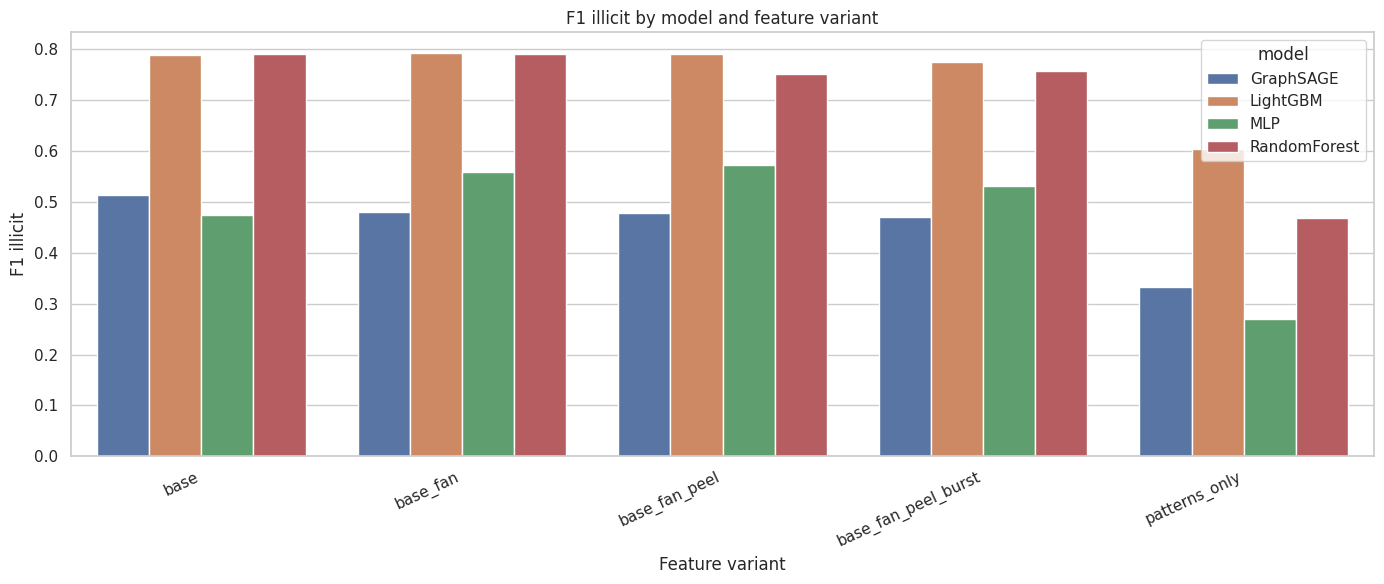

In [15]:
# строим график качества по ablation-вариантам
if not results_df.empty:
    fig = plt.figure(figsize=(14, 6))
    sns.barplot(data=results_df, x="variant", y="f1", hue="model")
    plt.title("F1 illicit by model and feature variant")
    plt.xlabel("Feature variant")
    plt.ylabel("F1 illicit")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    save_plot(fig, "ablation_f1_by_variant.png")

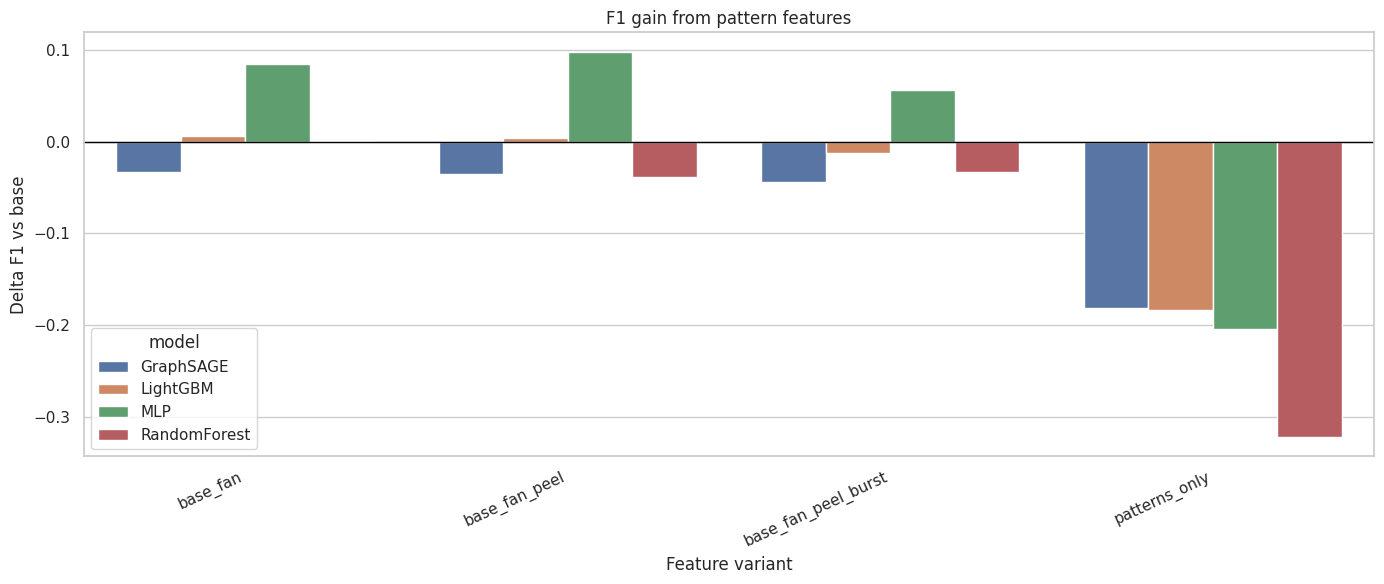

,model,variant,threshold,precision,recall,f1,mcc,roc_auc,pr_auc,precision_at_1pct,precision_at_5pct,f1_delta_vs_base
0,GraphSAGE,base,0.885,0.436211,0.625115,0.513852,0.482613,0.868132,0.506411,0.783133,0.591837,0.000000
1,GraphSAGE,base_fan,0.925,0.396407,0.611265,0.480930,0.448702,0.877734,0.454792,0.704819,0.541417,-0.032922
2,GraphSAGE,base_fan_peel,0.925,0.378437,0.648199,0.477876,0.450046,0.875088,0.451196,0.614458,0.597839,-0.035976
3,GraphSAGE,base_fan_peel_burst,0.895,0.372294,0.635272,0.469464,0.440290,0.870347,0.383746,0.578313,0.468187,-0.044388
4,GraphSAGE,patterns_only,0.545,0.224351,0.638042,0.331972,0.307857,0.812755,0.469160,0.903614,0.575030,-0.181880
5,LightGBM,base,0.195,0.873034,0.717452,0.787633,0.778626,0.928137,0.787730,1.000000,0.918367,0.000000
6,LightGBM,base_fan,0.175,0.881490,0.721145,0.793296,0.784904,0.928304,0.788820,0.993976,0.923169,0.005663
7,LightGBM,base_fan_peel,0.185,0.873884,0.722992,0.791309,0.782217,0.931993,0.788841,0.993976,0.920768,0.003676
8,LightGBM,base_fan_peel_burst,0.110,0.833333,0.724838,0.775309,0.762952,0.931670,0.792064,1.000000,0.919568,-0.012324
9,LightGBM,patterns_only,0.320,0.606710,0.601108,0.603896,0.576518,0.852667,0.584378,0.813253,0.735894,-0.183737


In [16]:
# считаем прирост F1 относительно base для каждой модели
if not results_df.empty:
    # base_scores фиксирует контрольную точку для каждой модели отдельно.
    base_scores = (
        results_df[results_df["variant"] == "base"]
        .set_index("model")["f1"]
        .to_dict()
    )
    results_df["f1_delta_vs_base"] = results_df.apply(
        lambda row: row["f1"] - base_scores.get(row["model"], np.nan),
        axis=1,
    )

    fig = plt.figure(figsize=(14, 6))
    sns.barplot(
        data=results_df[results_df["variant"] != "base"],
        x="variant",
        y="f1_delta_vs_base",
        hue="model",
    )
    plt.axhline(0, color="black", linewidth=1)
    plt.title("F1 gain from pattern features")
    plt.xlabel("Feature variant")
    plt.ylabel("Delta F1 vs base")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    save_plot(fig, "ablation_f1_delta_vs_base.png")

results_df

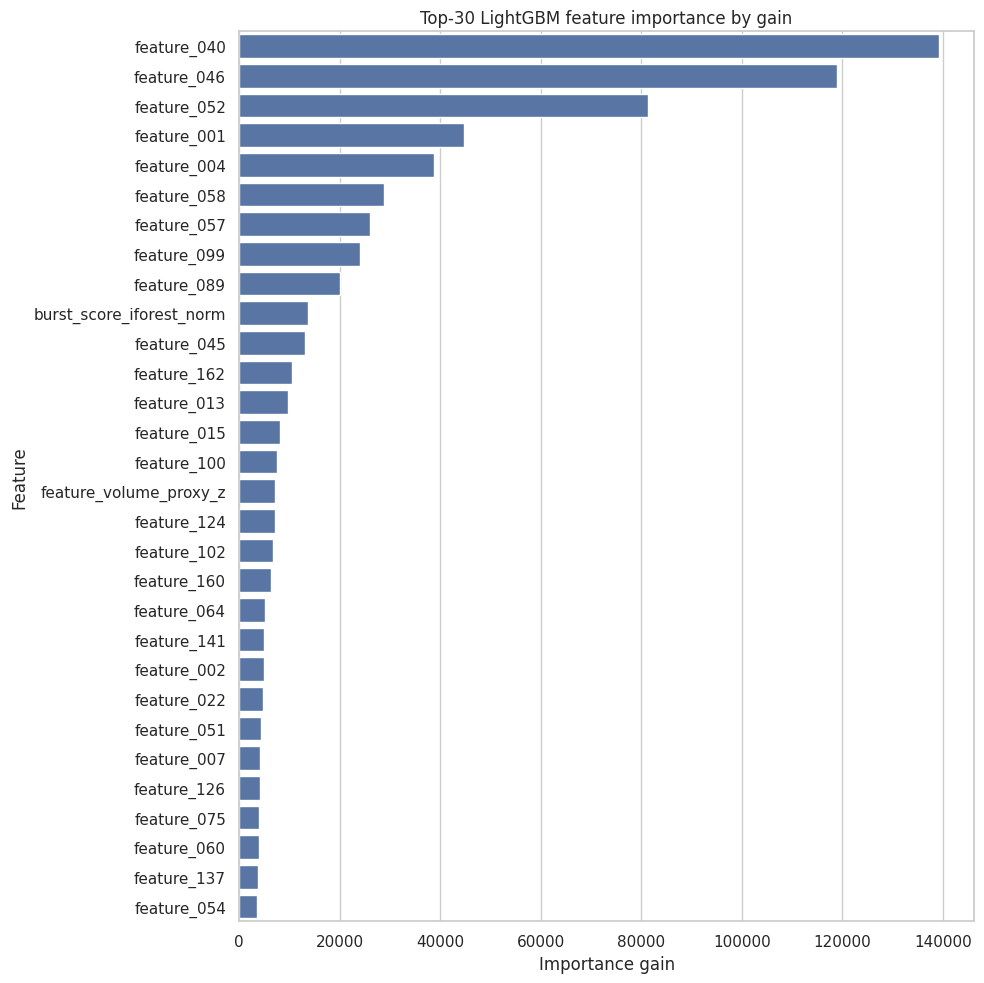

,feature,importance_gain,importance_split
41,feature_040,139210.480012,357
47,feature_046,118872.724664,336
53,feature_052,81277.817948,1288
2,feature_001,44788.926715,2577
5,feature_004,38805.915841,196
59,feature_058,28843.089116,441
58,feature_057,26021.588569,933
100,feature_099,24109.313191,490
90,feature_089,20016.529822,669
196,burst_score_iforest_norm,13581.926050,584


In [17]:
# строим importance LightGBM для полного набора признаков
importance_df = pd.DataFrame()
full_variant = "base_fan_peel_burst"

if full_variant in lgb_models:
    # full_variant показывает важность признаков в максимальном наборе base + fan + peel + burst.
    model = lgb_models[full_variant]
    full_columns = feature_variants[full_variant]
    importance_df = pd.DataFrame({ 
        "feature": full_columns,
        "importance_gain": model.feature_importance(importance_type="gain"),
        "importance_split": model.feature_importance(importance_type="split"),
    }).sort_values("importance_gain", ascending=False)

    top_importance = importance_df.head(30)
    fig = plt.figure(figsize=(10, 10))
    sns.barplot(data=top_importance, y="feature", x="importance_gain")
    plt.title("Top-30 LightGBM feature importance by gain")
    plt.xlabel("Importance gain")
    plt.ylabel("Feature")
    plt.tight_layout()
    save_plot(fig, "lightgbm_top30_feature_importance.png")

    importance_df.head(30)

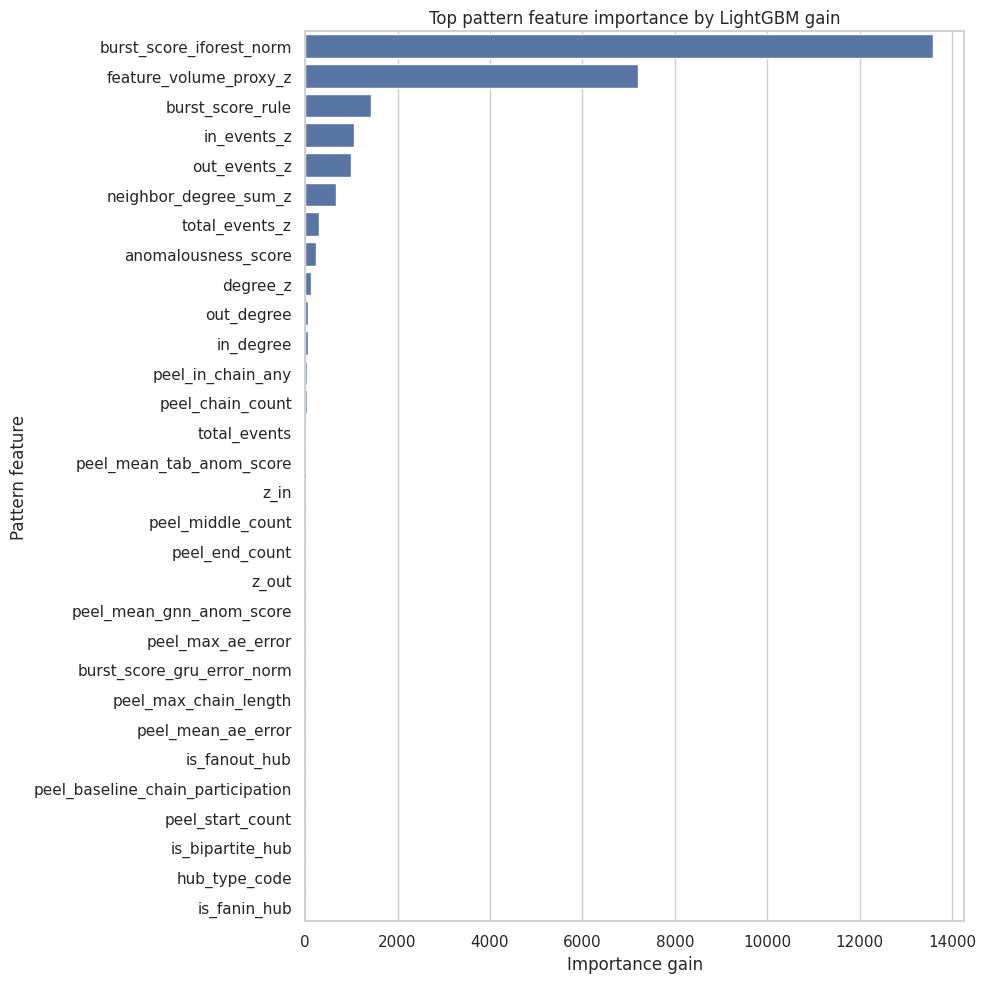

,feature,importance_gain,importance_split
196,burst_score_iforest_norm,13581.926050,584
194,feature_volume_proxy_z,7196.564767,702
195,burst_score_rule,1433.920651,345
189,in_events_z,1060.689962,529
190,out_events_z,985.032184,525
193,neighbor_degree_sum_z,675.617944,322
191,total_events_z,296.391605,110
173,anomalousness_score,231.345302,83
192,degree_z,122.162028,27
167,out_degree,71.029787,18


In [18]:
# отдельно смотрим важность только pattern-признаков
if not importance_df.empty:
    # pattern_importance отделяет новые признаки от исходных feature_*, чтобы оценить их самостоятельный вклад.
    pattern_importance = importance_df[importance_df["feature"].isin(pattern_features)].copy()
    top_pattern_importance = pattern_importance.head(30)

    fig = plt.figure(figsize=(10, 10))
    sns.barplot(data=top_pattern_importance, y="feature", x="importance_gain")
    plt.title("Top pattern feature importance by LightGBM gain")
    plt.xlabel("Importance gain")
    plt.ylabel("Pattern feature")
    plt.tight_layout()
    save_plot(fig, "lightgbm_pattern_feature_importance.png")

    display(top_pattern_importance)
else:
    pattern_importance = pd.DataFrame()

In [19]:
# сохраняем результаты эксперимента
# сохраняем метрики и importance отдельно, чтобы их можно было напрямую использовать в тексте и таблицах вкр.
results_df.to_csv(OUTPUT_DIR / "ablation_metrics.csv", index=False)
importance_df.to_csv(OUTPUT_DIR / "lightgbm_feature_importance.csv", index=False)
pattern_importance.to_csv(OUTPUT_DIR / "lightgbm_pattern_feature_importance.csv", index=False)

archive_path = shutil.make_archive(
    str(KAGGLE_WORKING / "ablation_visualizations_png"),
    "zip",
    VIS_DIR,
)

print(f"Saved metrics: {OUTPUT_DIR / 'ablation_metrics.csv'}")
print(f"Saved feature importance: {OUTPUT_DIR / 'lightgbm_feature_importance.csv'}")
print(f"Saved pattern importance: {OUTPUT_DIR / 'lightgbm_pattern_feature_importance.csv'}")
print(f"Visualization PNG directory: {VIS_DIR}")
print(f"Visualization PNG archive: {archive_path}")

Saved metrics: /kaggle/working/BITOC_WORK/outputs/elliptic_pattern_ablation/ablation_metrics.csv
Saved feature importance: /kaggle/working/BITOC_WORK/outputs/elliptic_pattern_ablation/lightgbm_feature_importance.csv
Saved pattern importance: /kaggle/working/BITOC_WORK/outputs/elliptic_pattern_ablation/lightgbm_pattern_feature_importance.csv


## Как интерпретировать результат

Главная проверка: сравнить `base` против `base_fan_peel_burst` внутри каждой модели.

Если `f1_delta_vs_base > 0`, pattern-признаки дали прирост. Если прирост есть у LightGBM и GraphSAGE одновременно, это сильный аргумент, что признаки полезны и для табличной модели, и для графовой нейросети.

`patterns_only` нужен как sanity check: если он дает качество выше случайного, значит найденные паттерны сами по себе содержат AML-сигнал, но основной вариант для ВКР — это `base + pattern features`.

## Краткие выводы по ablation

Добавление pattern-признаков подтверждает гипотезу частично: признаки `fan`, `peel` и `burst` содержат AML-сигнал, но эффект зависит от модели. Для табличных моделей полезнее всего оказались `fan`-признаки, для MLP — комбинация `fan + peel`, а для GraphSAGE добавление pattern-признаков ухудшило F1 относительно базовых признаков.

### LightGBM

- `base`: `F1 = 0.7876`, `PR-AUC = 0.7877`.
- `base_fan`: `F1 = 0.7933`, лучший F1 для LightGBM.
- `base_fan_peel`: `F1 = 0.7913`, тоже лучше base.
- `base_fan_peel_burst`: `F1 = 0.7753`, F1 хуже base, но `PR-AUC = 0.7921` выше base.
- `patterns_only`: `F1 = 0.6039`.

Вывод: для LightGBM `fan`-признаки дают небольшой, но реальный прирост F1. Полный набор `fan + peel + burst` улучшает ранжирование по `PR-AUC`, но снижает precision и итоговый F1.

### RandomForest

- `base`: `F1 = 0.7905`.
- `base_fan`: `F1 = 0.7911`, прирост минимальный.
- `base_fan_peel`: `F1 = 0.7517`, качество падает.
- `base_fan_peel_burst`: `F1 = 0.7573`, качество ниже base.
- `patterns_only`: `F1 = 0.4680`.

Вывод: RandomForest почти не выигрывает от pattern-признаков. Полный набор добавляет шум и ухудшает качество.

### MLP

- `base`: `F1 = 0.4741`.
- `base_fan`: `F1 = 0.5585`.
- `base_fan_peel`: `F1 = 0.5722`, лучший результат для MLP.
- `base_fan_peel_burst`: `F1 = 0.5308`.
- `patterns_only`: `F1 = 0.2696`, но recall высокий: `0.7138`.

Вывод: для MLP pattern-признаки наиболее полезны. Лучший вариант — `base + fan + peel`. Burst-признаки ухудшают F1, но могут усиливать recall-сигнал.

### GraphSAGE

- `base`: `F1 = 0.5139`, лучший F1 для GraphSAGE.
- `base_fan`: `F1 = 0.4809`.
- `base_fan_peel`: `F1 = 0.4779`.
- `base_fan_peel_burst`: `F1 = 0.4695`.
- `patterns_only`: `F1 = 0.3320`, `precision@1% = 0.9036`.

Вывод: в текущей реализации GraphSAGE лучше работает на исходных признаках. Pattern-признаки ухудшают F1, вероятно из-за шума, масштаба признаков или дублирования структурной информации, которую GNN уже частично извлекает из графа. При этом `patterns_only` хорошо ранжирует самый верх подозрительных узлов: `precision@1% = 0.9036`.

### Pattern-only

Только pattern-признаки без исходных Elliptic features дают самостоятельный AML-сигнал:

- LightGBM: `F1 = 0.6039`.
- RandomForest: `F1 = 0.4680`.
- GraphSAGE: `F1 = 0.3320`, но `precision@1% = 0.9036`.
- MLP: `F1 = 0.2696`, но recall `0.7138`.

Это значит, что паттерны сами по себе связаны с illicit-активностью, но как полноценная замена исходных признаков они слабее. Их лучше использовать как дополнительные признаки или как инструмент top-k ранжирования.

### Feature importance

Самые важные новые признаки по LightGBM:

- `burst_score_iforest_norm`;
- `feature_volume_proxy_z`;
- `burst_score_rule`;
- `in_events_z`;
- `out_events_z`;
- `neighbor_degree_sum_z`;
- `anomalousness_score`;
- `degree_z`;
- `in_degree`, `out_degree`;
- `peel_in_chain_any`, `peel_chain_count`.

Вывод: самый сильный вклад среди новых признаков дали burst-признаки, затем fan-degree признаки, затем peel-признаки. При этом высокая важность burst-признаков не всегда означает рост F1: они улучшают ранжирование и PR-AUC, но могут снижать precision при бинарной классификации.

### Итоговая формулировка для ВКР

Гипотеза о полезности pattern-признаков подтверждается частично. `Fan-in/Fan-out`, `Peel Chains` и `Burst Patterns` несут самостоятельный AML-сигнал и улучшают качество отдельных моделей: `fan` повышает F1 у LightGBM, `fan + peel` заметно улучшает MLP. Однако полный набор `fan + peel + burst` не является универсально лучшим: для RandomForest и GraphSAGE он ухудшает F1. Из результатов следует, что pattern-признаки целесообразно использовать вместе с ablation и отбором признаков, а не добавлять весь набор без фильтрации.